# Лабораторная работа № 1. Математика обучения нейронной сети
**Вариант 12.**

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display

torch.manual_seed(42)
torch.set_num_threads(1)
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': .3})
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())

PyTorch: 2.14.0
CUDA: False


## Задания 1–2
$L(w)=(w-3)^2$, $L'(w)=2(w-3)$. Минимум — $(3,0)$.
Слева от минимума производная отрицательна, справа положительна.

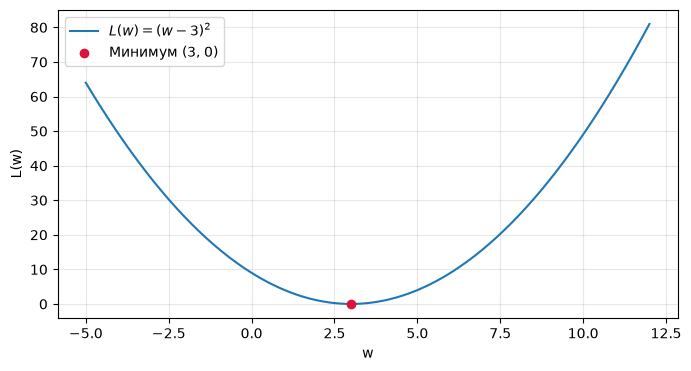

,w,L(w),dL/dw
0,-2,25,-10
1,0,9,-6
2,3,0,0
3,5,4,4
4,10,49,14


In [2]:
def loss(w):
    return (w - 3) ** 2

def grad(w):
    return 2 * (w - 3)

w_values = np.linspace(-5, 12, 300)
plt.plot(w_values, loss(w_values), label=r'$L(w)=(w-3)^2$')
plt.scatter([3], [0], color='crimson', zorder=5, label='Минимум (3, 0)')
plt.xlabel('w'); plt.ylabel('L(w)'); plt.legend()
plt.show()
points = np.array([-2, 0, 3, 5, 10])
display(pd.DataFrame({'w': points, 'L(w)': loss(points), 'dL/dw': grad(points)}));

## Задания 3–4
При $\eta=0{,}1$: $w_t-3=7\cdot0{,}8^t$, $L_t=49\cdot0{,}64^t$.
Параметр монотонно стремится к 3, потери убывают геометрически.
В историях индекс 0 соответствует начальному состоянию.

Epoch:  0   w: 10.000000000   loss: 49
Epoch:  5   w: 5.293760000   loss: 5.26133494
Epoch: 10   w: 3.751619277   loss: 0.564931537
Epoch: 15   w: 3.246290605   loss: 0.0606590619
Epoch: 20   w: 3.080704505   loss: 0.00651321718
Epoch: 25   w: 3.026445252   loss: 0.000699351369
Epoch: 30   w: 3.008665580   loss: 7.50922815e-05


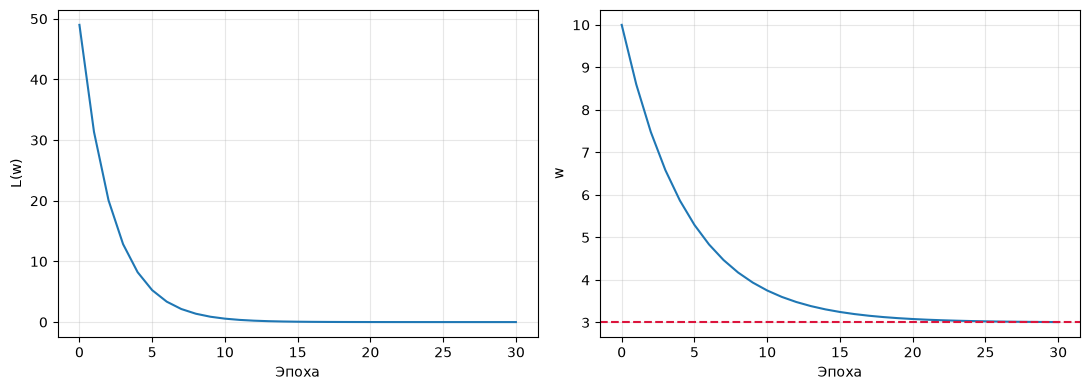

In [3]:
def manual_descent(lr, epochs=30):
    w = 10.0
    history_w, history_loss = [w], [loss(w)]
    for epoch in range(epochs):
        w -= lr * grad(w)
        history_w.append(w)
        history_loss.append(loss(w))
    return np.array(history_w), np.array(history_loss)

history_w, history_loss = manual_descent(0.1)
for epoch in range(0, 31, 5):
    print(f'Epoch: {epoch:2d}   w: {history_w[epoch]:.9f}   loss: {history_loss[epoch]:.9g}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_loss); axes[0].set(xlabel='Эпоха', ylabel='L(w)')
axes[1].plot(history_w); axes[1].axhline(3, color='crimson', ls='--')
axes[1].set(xlabel='Эпоха', ylabel='w')
fig.tight_layout(); plt.show()

## Задание 5
$w_t-3=7(1-2\eta)^t$, поэтому сходимость требует $0<\eta<1$.
При $\eta=0{,}5$ достаточно одного шага; при $\eta=1$ получаем цикл $10,-4,10,\ldots$;
при $\eta=1{,}1$ колебания растут.

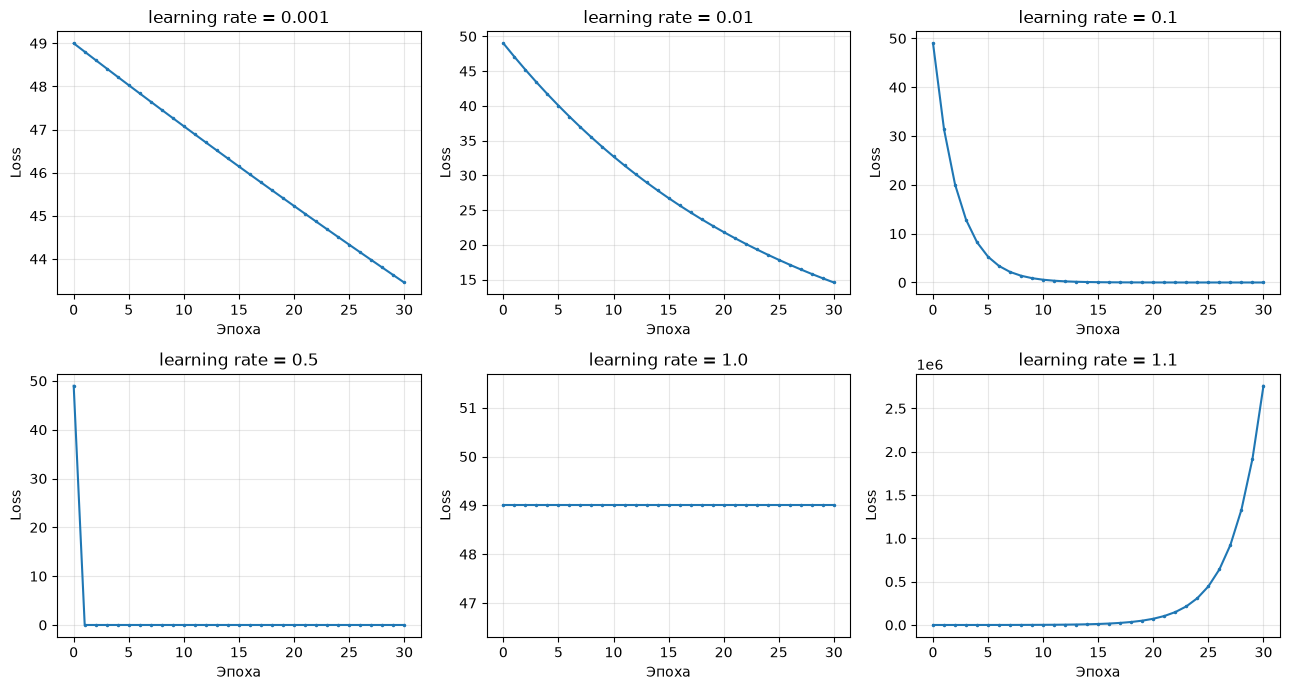

,Learning rate,Сходимость,Скорость,Поведение,Final Loss,w_30
0,0.001,Да,Очень медленно,Монотонное приближение,4.345388e+01,9.591956
1,0.010,Да,Медленно,Монотонное приближение,1.458010e+01,6.818390
2,0.100,Да,Быстро,Геометрическое убывание,7.509228e-05,3.008666
3,0.500,Да,Один шаг,Точный минимум,0.000000e+00,3.000000
4,1.000,Нет,Нет прогресса,Цикл из двух точек,4.900000e+01,10.000000
5,1.100,Нет,Расходимость,Растущие колебания,2.761028e+06,1664.634197


In [4]:
lr_descriptions = [
    (0.001, 'Да', 'Очень медленно', 'Монотонное приближение'),
    (0.01, 'Да', 'Медленно', 'Монотонное приближение'),
    (0.1, 'Да', 'Быстро', 'Геометрическое убывание'),
    (0.5, 'Да', 'Один шаг', 'Точный минимум'),
    (1.0, 'Нет', 'Нет прогресса', 'Цикл из двух точек'),
    (1.1, 'Нет', 'Расходимость', 'Растущие колебания'),
]
rows=[]
fig, axes=plt.subplots(2, 3, figsize=(13, 7))
for ax, (lr, conv, speed, behavior) in zip(axes.flat, lr_descriptions):
    ws, ls = manual_descent(lr)
    rows.append({'Learning rate': lr, 'Сходимость': conv, 'Скорость': speed,
                 'Поведение': behavior, 'Final Loss': ls[-1], 'w_30': ws[-1]})
    ax.plot(ls, marker='.', ms=3)
    ax.set(title=f'learning rate = {lr}', xlabel='Эпоха', ylabel='Loss')
fig.tight_layout(); plt.show()
display(pd.DataFrame(rows));

## Задание 6
Центральная разность для этой квадратичной функции точна без округления.
Малое расхождение возникает из-за арифметики с плавающей точкой.

In [5]:
def numerical_gradient(f, w, h=1e-5):
    return (f(w + h) - f(w - h)) / (2 * h)

points = np.array([-1., 0., 2., 5., 10.])
analytic = grad(points)
numeric = numerical_gradient(loss, points)
display(pd.DataFrame({'w': points, 'Аналитическая': analytic, 'Численная': numeric,
                    'Абсолютная ошибка': np.abs(analytic - numeric)}))

,w,Аналитическая,Численная,Абсолютная ошибка
0,-1.0,-8.0,-8.0,2.140448e-10
1,0.0,-6.0,-6.0,3.930634e-11
2,2.0,-2.0,-2.0,1.310241e-11
3,5.0,4.0,4.0,1.514313e-10
4,10.0,14.0,14.0,5.300098e-10


## Задания 7–9
`requires_grad=True` включает отслеживание операций; `backward()` вычисляет градиент.
При $w=10$ результат равен $2(10-3)=14$. Параметр обновляем внутри `no_grad()`.

Без очистки два вызова `backward()` при $w=5$ дают градиенты 4 и 8.
> Почему PyTorch не обнуляет градиенты автоматически?

PyTorch складывает вклады, что позволяет накапливать градиенты по нескольким батчам.
Для независимых шагов обучения нужен `zero_grad()`.


In [6]:
w = torch.tensor(10.0, requires_grad=True)
value = (w - 3) ** 2
value.backward()
print('w =', w, '\nloss =', value, '\ngradient =', w.grad)

w = torch.tensor(10.0, requires_grad=True)
torch_history = [w.item()]
for epoch in range(30):
    value = (w - 3) ** 2
    value.backward()
    with torch.no_grad():
        w -= 0.1 * w.grad
    w.grad.zero_()
    torch_history.append(w.item())
print(f'После 30 шагов: w={w.item():.9f}, Loss={((w-3)**2).item():.9g}')
print('Максимальное отличие от ручного спуска:', np.max(np.abs(history_w - torch_history)))

w = torch.tensor(5.0, requires_grad=True)
accumulated=[]
for _ in range(2):
    value = (w - 3) ** 2
    value.backward()
    accumulated.append(w.grad.item())
print('Без обнуления:', accumulated)

w = tensor(10., requires_grad=True) 
loss = tensor(49., grad_fn=<PowBackward0>) 
gradient = tensor(14.)
После 30 шагов: w=3.008665562, Loss=7.50919571e-05
Максимальное отличие от ручного спуска: 5.874633792757322e-07
Без обнуления: [4.0, 8.0]


## Задания 10–11
Линии уровня — окружности с центром $(2,-3)$.
Антиградиент направлен к центру, в сторону наибольшего локального убывания функции.
Обе компоненты ошибки уменьшаются в 0,8 раза за шаг.

 0: w1=8.0000000, w2=5.0000000, loss=100
 5: w1=3.9660802, w2=-0.3785601, loss=10.737419
10: w1=2.6442451, w2=-2.1410067, loss=1.1529213
15: w1=2.2111063, w2=-2.7185252, loss=0.12379395
20: w1=2.0691752, w2=-2.9077663, loss=0.013292262
25: w1=2.0226674, w2=-2.9697769, loss=0.0014272491
30: w1=2.0074277, w2=-2.9900966, loss=0.00015324856
35: w1=2.0024338, w2=-2.9967549, loss=1.6454043e-05
40: w1=2.0007975, w2=-2.9989367, loss=1.7667289e-06
45: w1=2.0002613, w2=-2.9996517, loss=1.896147e-07
50: w1=2.0000858, w2=-2.9998860, loss=2.0354719e-08


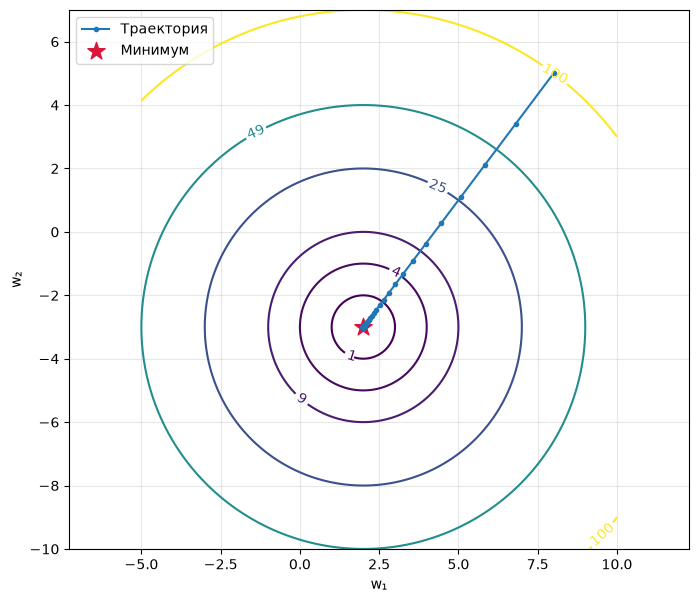

In [7]:
w1 = torch.tensor(8.0, requires_grad=True)
w2 = torch.tensor(5.0, requires_grad=True)
path = [[w1.item(), w2.item()]]
for epoch in range(51):
    value = (w1 - 2) ** 2 + (w2 + 3) ** 2
    if epoch % 5 == 0:
        print(f'{epoch:2d}: w1={w1.item():.7f}, w2={w2.item():.7f}, loss={value.item():.8g}')
    if epoch == 50:
        break
    value.backward()
    with torch.no_grad():
        w1 -= 0.1 * w1.grad
        w2 -= 0.1 * w2.grad
    w1.grad.zero_(); w2.grad.zero_()
    path.append([w1.item(), w2.item()])
path = np.array(path)
u, v = np.meshgrid(np.linspace(-5, 10, 200), np.linspace(-10, 7, 200))
plt.figure(figsize=(8, 7))
contours = plt.contour(u, v, (u-2)**2+(v+3)**2, levels=[1, 4, 9, 25, 49, 100])
plt.clabel(contours)
plt.plot(path[:, 0], path[:, 1], 'o-', ms=3, label='Траектория')
plt.scatter([2], [-3], marker='*', s=170, color='crimson', label='Минимум')
plt.xlabel('w₁'); plt.ylabel('w₂'); plt.axis('equal'); plt.legend()
plt.show()

## Задания 12–14
Обучаем $\hat y=wx+b$ на данных $y=4x-2+\varepsilon$, $\varepsilon\sim N(0;0{,}8^2)$.
$w$ задаёт наклон, $b$ — смещение. Из-за шума найденные значения немного отличаются от 4 и −2.

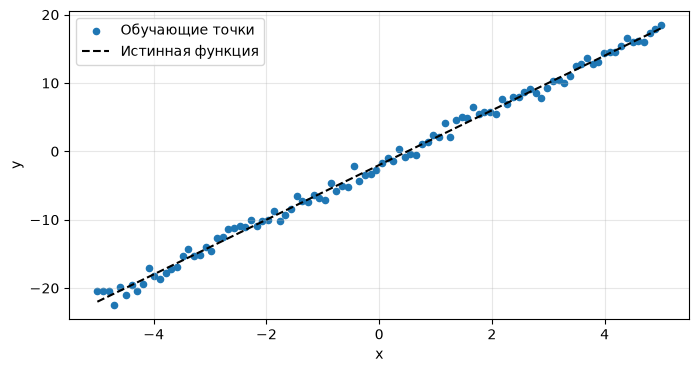

w, b = [3.995283365249634, -1.952184796333313] ; Final Loss = 0.6162578463554382


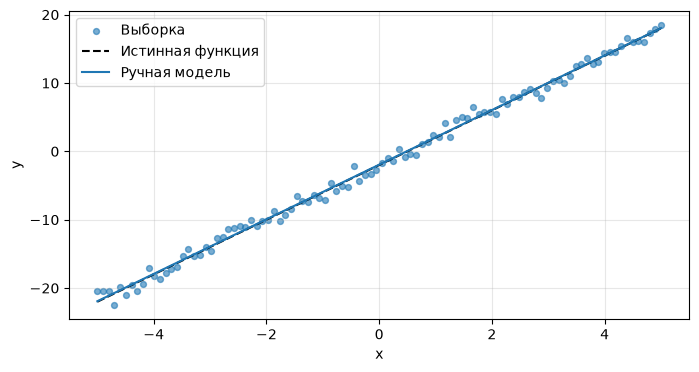

In [8]:
torch.manual_seed(42)
x_line = torch.linspace(-5, 5, 100).reshape(-1, 1)
y_line = 4 * x_line - 2 + torch.randn_like(x_line) * 0.8
plt.scatter(x_line.numpy(), y_line.numpy(), s=20, label='Обучающие точки')
plt.plot(x_line.numpy(), (4*x_line-2).numpy(), 'k--', label='Истинная функция')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
initial_w, initial_b = w.detach().clone(), b.detach().clone()
manual_mse = [((w*x_line+b-y_line)**2).mean().item()]
for epoch in range(1000):
    prediction = w * x_line + b
    value = ((prediction-y_line)**2).mean()
    value.backward()
    with torch.no_grad():
        w -= 0.01 * w.grad
        b -= 0.01 * b.grad
        manual_mse.append(((w*x_line+b-y_line)**2).mean().item())
    w.grad.zero_(); b.grad.zero_()
manual_params = [w.item(), b.item()]
print('w, b =', manual_params, '; Final Loss =', manual_mse[-1])
with torch.no_grad():
    prediction = w * x_line + b
plt.scatter(x_line.numpy(), y_line.numpy(), s=18, alpha=.6, label='Выборка')
plt.plot(x_line.numpy(), (4*x_line-2).numpy(), 'k--', label='Истинная функция')
plt.plot(x_line.numpy(), prediction.numpy(), label='Ручная модель')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

## Задания 15–16
`nn.Linear(1, 1)` вычисляет то же $wx+b$. Размер веса — `(1, 1)`, смещения — `(1,)`.
Берём одинаковые начальные параметры и шаг: ручное обновление и SGD должны дать одинаковую сходимость.

Начальные параметры: Parameter containing:
tensor([[-0.5672]], requires_grad=True) Parameter containing:
tensor([-0.5706], requires_grad=True)
Размеры: torch.Size([1, 1]) torch.Size([1])


,Метод,w,b,Final Loss
0,Ручное обновление,3.995283,-1.952185,0.616258
1,nn.Linear + SGD,3.995283,-1.952185,0.616258


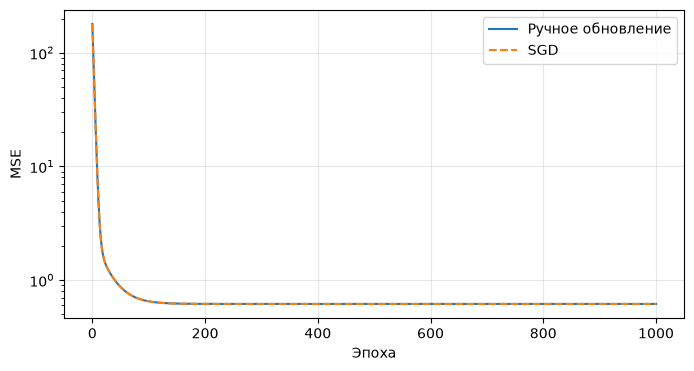

In [9]:
linear = nn.Linear(1, 1)
with torch.no_grad():
    linear.weight.copy_(initial_w.reshape(1, 1))
    linear.bias.copy_(initial_b)
print('Начальные параметры:', linear.weight, linear.bias)
print('Размеры:', linear.weight.shape, linear.bias.shape)
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)
criterion = nn.MSELoss()
sgd_mse = [criterion(linear(x_line), y_line).item()]
for epoch in range(1000):
    optimizer.zero_grad()
    value = criterion(linear(x_line), y_line)
    value.backward()
    optimizer.step()
    with torch.no_grad():
        sgd_mse.append(criterion(linear(x_line), y_line).item())
sgd_params = [linear.weight.item(), linear.bias.item()]
display(pd.DataFrame([
    {'Метод': 'Ручное обновление', 'w': manual_params[0], 'b': manual_params[1], 'Final Loss': manual_mse[-1]},
    {'Метод': 'nn.Linear + SGD', 'w': sgd_params[0], 'b': sgd_params[1], 'Final Loss': sgd_mse[-1]},

]))
plt.semilogy(manual_mse, label='Ручное обновление')
plt.semilogy(sgd_mse, '--', label='SGD')
plt.xlabel('Эпоха'); plt.ylabel('MSE'); plt.legend(); plt.show()

Параметры и итоговые потери совпали с точностью округления; кривые сходимости накладываются друг на друга.

## Задания 17–18


MSE: линейная = 7.324078559875488 , нелинейная = 0.039532218128442764


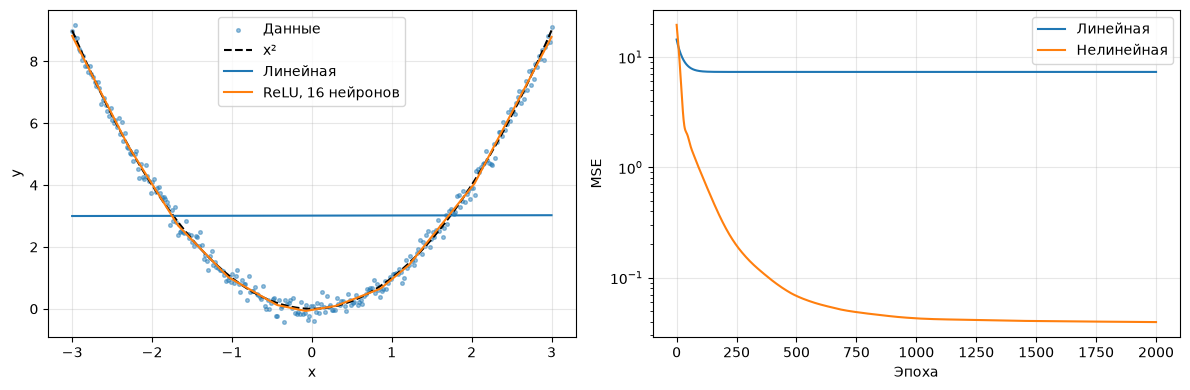

In [10]:
torch.manual_seed(43)
x_quad = torch.linspace(-3, 3, 300).reshape(-1, 1)
y_quad = x_quad ** 2 + torch.randn_like(x_quad) * 0.2

def fit(model, x, y, optimizer, epochs):
    history = [nn.functional.mse_loss(model(x), y).item()]
    for _ in range(epochs):
        optimizer.zero_grad()
        value = nn.functional.mse_loss(model(x), y)
        value.backward()
        optimizer.step()
        with torch.no_grad():
            history.append(nn.functional.mse_loss(model(x), y).item())
    return history

torch.manual_seed(44)
quad_linear = nn.Linear(1, 1)
linear_quad_loss = fit(quad_linear, x_quad, y_quad,
                      torch.optim.SGD(quad_linear.parameters(), lr=.01), 2000)
torch.manual_seed(45)
quad_net = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
quad_initial = copy.deepcopy(quad_net.state_dict())
nonlinear_quad_loss = fit(quad_net, x_quad, y_quad,
                         torch.optim.Adam(quad_net.parameters(), lr=.01), 2000)
with torch.no_grad():
    pred_linear = quad_linear(x_quad).numpy()
    pred_net = quad_net(x_quad).numpy()
print('MSE: линейная =', linear_quad_loss[-1], ', нелинейная =', nonlinear_quad_loss[-1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x_quad.numpy(), y_quad.numpy(), s=7, alpha=.45, label='Данные')
axes[0].plot(x_quad.numpy(), x_quad.numpy()**2, 'k--', label='x²')
axes[0].plot(x_quad.numpy(), pred_linear, label='Линейная')
axes[0].plot(x_quad.numpy(), pred_net, label='ReLU, 16 нейронов')
axes[0].set(xlabel='x', ylabel='y'); axes[0].legend()
axes[1].semilogy(linear_quad_loss, label='Линейная')
axes[1].semilogy(nonlinear_quad_loss, label='Нелинейная')
axes[1].set(xlabel='Эпоха', ylabel='MSE'); axes[1].legend()
fig.tight_layout(); plt.show()

> Какая модель лучше описывает зависимость?

Сеть с ReLU: её MSE около 0,04 против 7,32 у линейной модели.

> Почему число эпох не решает проблему линейной модели?

Прямая не может воспроизвести кривизну $x^2$; увеличение числа эпох не меняет класс функций модели.

> Какую роль выполняет `ReLU`?

ReLU добавляет нелинейность и позволяет сети строить кусочно-линейную аппроксимацию параболы.

> Почему два линейных слоя без нелинейности всё равно эквивалентны одному линейному преобразованию?

Композиция остаётся аффинной: $W_2(W_1x+b_1)+b_2=(W_2W_1)x+W_2b_1+b_2$.


## Задания 19–20

При $x=2$, $w=3$, $b=1$: $z=7$, $a=\operatorname{ReLU}(7)=7$, $L=9$.
Частные производные: $\partial L/\partial a=-6$, $\partial a/\partial z=1$,
$\partial z/\partial w=2$, $\partial z/\partial b=1$.
По цепному правилу $\partial L/\partial w=-12$, $\partial L/\partial b=-6$.

Первый слой имеет $16\cdot1=16$ весов и 16 смещений, второй — $1\cdot16=16$ весов
и 1 смещение. Итого **49 параметров**. У ReLU обучаемых параметров нет.

In [11]:
x = torch.tensor(2.)
w = torch.tensor(3., requires_grad=True)
b = torch.tensor(1., requires_grad=True)
z = w*x+b
a = torch.relu(z)
value = (a-10)**2
value.backward()
print('z, a, L:', z.item(), a.item(), value.item())
print('Autograd: dL/dw, dL/db:', w.grad.item(), b.grad.item())
for name, parameter in quad_net.named_parameters():
    print(name, tuple(parameter.shape), parameter.numel())
parameter_count = sum(p.numel() for p in quad_net.parameters() if p.requires_grad)
print('Всего:', parameter_count)

z, a, L: 7.0 7.0 9.0
Autograd: dL/dw, dL/db: -12.0 -6.0
0.weight (16, 1) 16
0.bias (16,) 16
2.weight (1, 16) 16
2.bias (1,) 1
Всего: 49


## Мини-исследование
Сравним три learning rate Adam при одинаковых данных, начальных весах и 2 000 эпохах.

In [12]:
mini_rows = []
for lr in [.001, .01, .05]:
    net = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
    net.load_state_dict(quad_initial)
    h = fit(net, x_quad, y_quad, torch.optim.Adam(net.parameters(), lr=lr), 2000)
    mini_rows.append({'№': len(mini_rows)+1, 'Learning rate': lr, 'Final Loss': h[-1],
                     'Наблюдение': 'Медленное обучение' if lr == .001 else 'Малая ошибка'})
display(pd.DataFrame(mini_rows))

,№,Learning rate,Final Loss,Наблюдение
0,1,0.001,0.240985,Медленное обучение
1,2,0.010,0.039532,Малая ошибка
2,3,0.050,0.038398,Малая ошибка


При шаге 0,001 сеть не успела хорошо обучиться. Из проверенных значений наименьшую ошибку дал шаг 0,05.

## Вариант 12
$y=2x_1-3x_2+5$, $x_1,x_2\in[-10,10]$. Модель — `nn.Linear(2, 1)`, потери — MSE,
оптимизатор — SGD. Шум не добавляем: он не задан.

Проверим $N=20,50,100,500,1000$ при шаге 0,01 и 1 000 эпохах.
Меньшие выборки берём из начала одной общей выборки; начальные веса одинаковые.
Для сравнения ошибки вне обучающих точек используем одну сетку по всему квадрату.

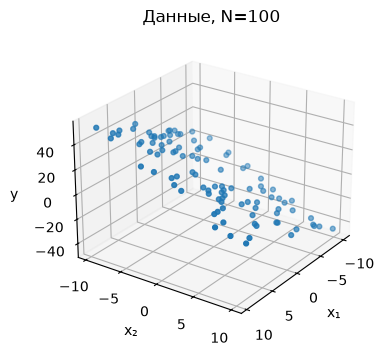

In [13]:
torch.manual_seed(12)
x_all = 20 * torch.rand(1000, 2) - 10

def target(x):
    return 2*x[:, :1] - 3*x[:, 1:2] + 5

y_all = target(x_all)
torch.manual_seed(120)
initial_state = copy.deepcopy(nn.Linear(2, 1).state_dict())
u, v = torch.meshgrid(torch.linspace(-10, 10, 41), torch.linspace(-10, 10, 41), indexing='ij')
x_grid = torch.stack([u.flatten(), v.flatten()], dim=1)
y_grid = target(x_grid)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x_all[:100, 0], x_all[:100, 1], y_all[:100, 0], s=12)
ax.set(xlabel='x₁', ylabel='x₂', zlabel='y', title='Данные, N=100')
ax.view_init(elev=25, azim=35)
plt.show()

In [14]:
def train_variant(n, lr=.01, epochs=1000):
    x, y = x_all[:n], y_all[:n]
    model = nn.Linear(2, 1)
    model.load_state_dict(initial_state)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = fit(model, x, y, optimizer, epochs)
    with torch.no_grad():
        grid_mse = nn.functional.mse_loss(model(x_grid), y_grid).item()
    w1, w2 = model.weight.detach().flatten().tolist()
    row = {'N': n, 'Learning rate': lr, 'Epochs': epochs, 'Final Loss': history[-1],
           'MSE на сетке': grid_mse, 'w1': w1, 'w2': w2, 'b': model.bias.item()}
    return model, history, row

sizes = [20, 50, 100, 500, 1000]
models, histories, rows = {}, {}, []
for n in sizes:
    models[n], histories[n], row = train_variant(n)
    row['Наблюдение'] = 'Коэффициенты близки к (2, −3, 5)'
    rows.append(row)
results = pd.DataFrame(rows)
results.index = np.arange(1, 6)
display(results)

,N,Learning rate,Epochs,Final Loss,MSE на сетке,w1,w2,b,Наблюдение
1,20,0.01,1000,1.453742e-10,1.631545e-10,2.0,-3.0,4.999988,"Коэффициенты близки к (2, −3, 5)"
2,50,0.01,1000,1.447233e-10,1.542375e-10,2.0,-3.0,4.999988,"Коэффициенты близки к (2, −3, 5)"
3,100,0.01,1000,1.375531e-10,1.379906e-10,2.0,-3.0,4.999988,"Коэффициенты близки к (2, −3, 5)"
4,500,0.01,1000,1.364242e-10,1.338503e-10,2.0,-3.0,4.999988,"Коэффициенты близки к (2, −3, 5)"
5,1000,0.01,1000,1.380836e-10,1.377250e-10,2.0,-3.0,4.999988,"Коэффициенты близки к (2, −3, 5)"


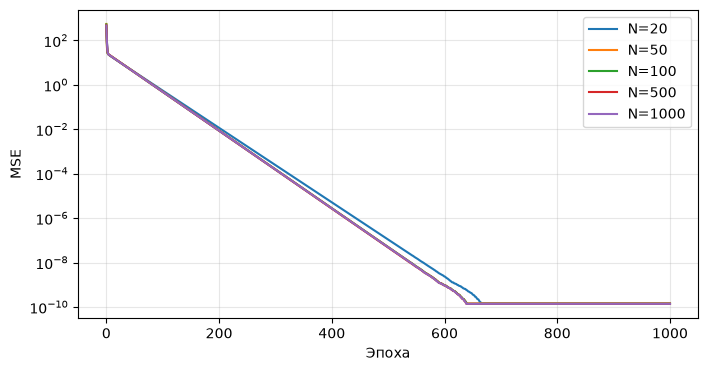

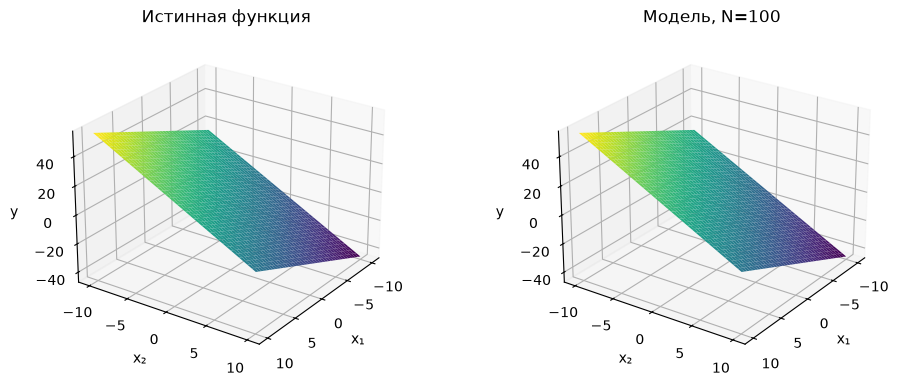

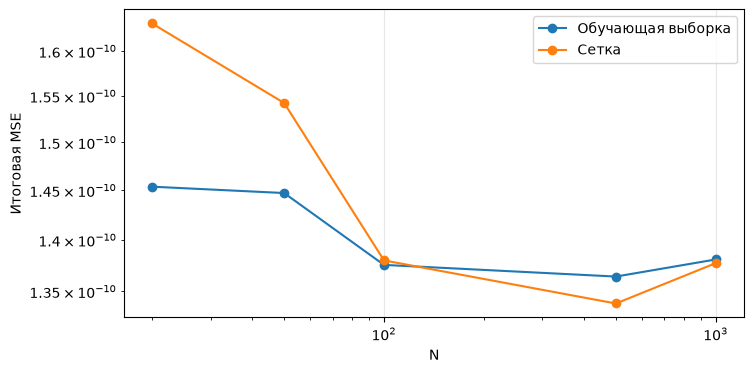

In [15]:
for n in sizes:
    plt.semilogy(histories[n], label=f'N={n}')
plt.xlabel('Эпоха'); plt.ylabel('MSE'); plt.legend()
plt.show()

with torch.no_grad():
    prediction = models[100](x_grid).reshape(41, 41).numpy()
fig = plt.figure(figsize=(10, 4))
for i, (z, title) in enumerate([(y_grid.reshape(41, 41).numpy(), 'Истинная функция'),
                               (prediction, 'Модель, N=100')], 1):
    ax = fig.add_subplot(1, 2, i, projection='3d')
    ax.plot_surface(u.numpy(), v.numpy(), z, cmap='viridis')
    ax.set(xlabel='x₁', ylabel='x₂', zlabel='y', title=title)
    ax.view_init(elev=25, azim=35)
plt.tight_layout(); plt.show()

plt.loglog(results['N'], results['Final Loss'], 'o-', label='Обучающая выборка')
plt.loglog(results['N'], results['MSE на сетке'], 'o-', label='Сетка')
plt.xlabel('N'); plt.ylabel('Итоговая MSE'); plt.legend()
plt.show()

## Дополнительный эксперимент
При N = 100 меняем только learning rate: 0,001; 0,01; 0,02. Число эпох — 1 000.

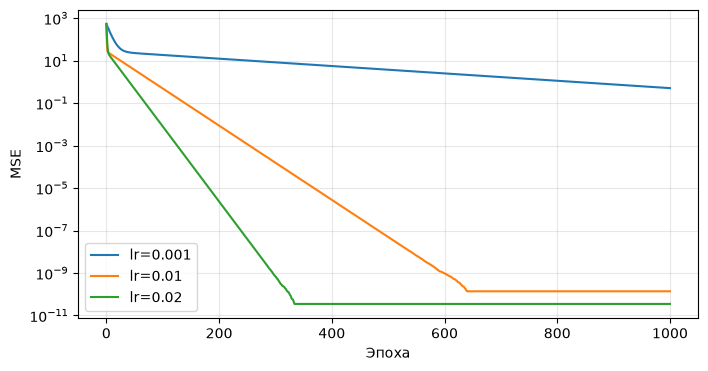

,Learning rate,Final Loss,w1,w2,b
0,0.001,5.035946e-01,1.9994,-3.006909,4.289268
1,0.010,1.375531e-10,2.0000,-3.000000,4.999988
2,0.020,3.488822e-11,2.0000,-3.000000,4.999994


In [16]:
lr_rows = []
for lr in [.001, .01, .02]:
    model, history, row = train_variant(100, lr=lr)
    lr_rows.append({'Learning rate': lr, 'Final Loss': row['Final Loss'],
                    'w1': row['w1'], 'w2': row['w2'], 'b': row['b']})
    plt.semilogy(history, label=f'lr={lr}')
plt.xlabel('Эпоха'); plt.ylabel('MSE'); plt.legend()
plt.show()
display(pd.DataFrame(lr_rows))

## Вывод

> Какую зависимость или границу решения должна была восстановить модель?

Плоскость $y=2x_1-3x_2+5$ на квадрате $[-10,10]^2$.

> Какая архитектура использовалась?

`nn.Linear(2, 1)`: два веса и смещение.

> Как менялся Loss?

При шаге 0,01 Loss убывал до $10^{-10}$; коэффициенты приблизились к (2, −3, 5).

> Как исследуемый параметр влиял на обучение?

Уже N = 20 хватило для малой ошибки. Увеличение выборки не давало строго монотонного улучшения.

> Какая конфигурация оказалась наиболее эффективной?

N = 20 достаточно по точности при меньшем числе вычислений за эпоху. В дополнительном опыте при N = 100 быстрее всего сходился шаг 0,02.

> Возникала ли нестабильность?

Нет, при проверенных размерах выборки и шагах обучение было устойчивым.

> Наблюдалось ли недообучение?

При шаге 0,001 за 1 000 эпох оставалась заметная ошибка; шаги 0,01 и 0,02 давали малую ошибку.

> Наблюдалось ли переобучение?

Признаков нет: ошибки на обучающих точках и сетке малы.

> Как результат можно объяснить математически?

Модель содержит истинную линейную функцию. Без шума и при полном ранге матрицы признаков её три коэффициента определяются однозначно.


## Контрольные вопросы

> Что с математической точки зрения представляет собой нейронная сеть?

Нейросеть — параметризованная композиция преобразований.

> Что является параметрами модели?

Параметры модели — веса и смещения.

> Что показывает функция потерь?

Loss измеряет ошибку предсказаний.

> Что показывает производная функции потерь по параметру?

Производная показывает, как локально меняется Loss при изменении параметра.

> Что такое градиент?

Градиент — вектор частных производных.

> В каком направлении указывает градиент?

Он направлен в сторону наибольшего локального роста функции.

> Почему при градиентном спуске используется $-\nabla L$?

Антиградиент задаёт направление наибольшего локального убывания.

> Что такое learning rate?

Learning rate — множитель градиента при обновлении параметров.

> Что происходит при слишком маленьком learning rate?

Малый шаг замедляет обучение.

> Что происходит при слишком большом learning rate?

Большой шаг может вызвать колебания и расходимость.

> Чем аналитическое вычисление производной отличается от численного?

Аналитическая производная получается из формулы, численная — из разностей значений функции.

> Что означает `requires_grad=True`?

`requires_grad=True` включает отслеживание операций для вычисления градиентов.

> Что выполняет `loss.backward()`?

`backward()` выполняет обратный проход и накапливает градиенты в `.grad`.

> Почему требуется `zero_grad()`?

`zero_grad()` очищает градиенты предыдущего шага.

> Почему PyTorch накапливает градиенты?

Накопление нужно для суммирования вкладов нескольких потерь или батчей.

> Что представляет собой вычислительный граф?

Вычислительный граф хранит операции и зависимости между тензорами.

> Как цепное правило связано с backpropagation?

Backpropagation применяет цепное правило от выхода к параметрам.

> Что выполняет `optimizer.step()`?

`optimizer.step()` обновляет параметры по вычисленным градиентам.

> Чем архитектура модели отличается от процесса обучения?

Архитектура задаёт класс функций; обучение подбирает параметры.

> Почему несколько линейных слоёв без нелинейности можно заменить одним линейным преобразованием?

Композиция аффинных преобразований снова аффинна.

> Какую роль играет функция активации?

Активация позволяет описывать нелинейные зависимости.

> Почему `nn.Linear` не способен аппроксимировать $x^2$ на всём рассматриваемом интервале?

Прямая не воспроизводит кривизну $x^2$ на интервале.

> Почему глубокая сеть может описывать более сложные зависимости?

Глубина позволяет составлять более сложные нелинейные преобразования.

> Что такое обучаемый параметр?

Обучаемый параметр — величина, которую изменяют при обучении.

> Как посчитать количество обучаемых параметров слоя `nn.Linear`?

В `Linear(m, n)` с bias $mn+n$ параметров.

> Как размер выборки может повлиять на обучение?

Большая выборка лучше покрывает область и уменьшает влияние шума, но увеличивает стоимость эпохи.

> Как шум влияет на функцию потерь?

Шум повышает остаточную ошибку относительно истинной зависимости.

> Почему разные оптимизаторы могут давать разные траектории обучения?

Оптимизаторы по-разному используют градиенты и историю обновлений.

> Что такое норма градиента?

Норма градиента — $\sqrt{\sum_j(\partial L/\partial\theta_j)^2}$.

> Как определить, что процесс оптимизации нестабилен?

Признаки нестабильности: рост или сильные колебания Loss, большие градиенты, `NaN` и `Inf`.
